# Seminário — Clustering de áudio de drones

Este notebook concentra o percurso experimental. O objetivo é comparar representações STFT e DWT (wavelets) e investigar como elas afetam a estrutura de clusters de áudio, sem usar rótulos durante o ajuste.

## 1 — Etapa inicial: ambiente, dados e princípios

**Pergunta do seminário.** Representações acústicas diferentes revelam estruturas de cluster diferentes em áudio de drones? Em particular, queremos saber se STFT e wavelets destacam assinaturas associadas a drones ou apenas a condições acústicas/ruídos.

**Papel dos datasets.** Al Emadi é o estudo metodológico inicial; DREGON será usado para investigar ruído e segmentação; Drone Audio será a validação em maior escala. Yi et al. fica fora deste recorte para evitar que volume e mudanças de domínio escondam decisões metodológicas ainda não validadas.

**Princípio experimental.** Durante extração, redução dimensional e clustering, os rótulos não são fornecidos ao modelo. Eles aparecem somente na interpretação pós-hoc: isso permite perguntar se grupos descobertos sem supervisão correspondem a algo semanticamente reconhecível.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents, cwd / 'datasets' / 'davi' / 'clustering_audio']
ROOT = next((path for path in candidates if (path / 'config').exists() and (path / 'scripts').exists()), None)
assert ROOT is not None, 'Não foi possível localizar clustering_audio.'
SCRIPTS, MANIFESTS = ROOT / 'scripts', ROOT / 'data' / 'manifests'
FEATURES, MODELS = ROOT / 'data' / 'features', ROOT / 'outputs' / 'models'
METRICS, FIGURES = ROOT / 'outputs' / 'metrics', ROOT / 'outputs' / 'figures'
RUN_PIPELINE = False  # Mude para True apenas nas etapas que desejar reexecutar.
print(f'Pipeline: {ROOT}')

Pipeline: F:\Seminario\Seminario-Clustering\datasets\davi\clustering_audio


## 2 — Etapa inicial exploratória: piloto STFT não balanceado

**Hipótese exploratória H1.** Mesmo em uma amostra aleatória do Al Emadi, atributos STFT podem revelar regiões densas no espaço acústico.

**Desenho.** Sorteamos 500 áudios, aplicamos STFT com janela Hann de 40 ms e hop de 20 ms, resumimos MFCCs e descritores espectrais ao longo do tempo e testamos K-Means para múltiplos valores de `k`.

**O que esperar antes de executar.** Como `unknown` é muito maior que `bebop_1` e `membo_1`, esperamos que os clusters capturem principalmente variedades de ruído. Uma silhouette baixa/moderada não invalida o pipeline; apenas indica que o dataset não forma grupos naturalmente muito separados nessa representação.

In [2]:
pilot_metrics_path = METRICS / 'al_emadi_piloto.csv'
pilot_metrics = pd.read_csv(pilot_metrics_path).sort_values('silhouette', ascending=False)
display(pilot_metrics.style.format({'silhouette': '{:.3f}', 'calinski_harabasz': '{:.1f}', 'davies_bouldin': '{:.3f}'}))

best_stft_k = int(pilot_metrics.iloc[0].clusters)
print(f'Melhor k pelo silhouette do piloto: {best_stft_k}')

,run,samples,clusters,silhouette,calinski_harabasz,davies_bouldin
3,clusters_kmeans_k3,500,3,0.202,74.5,1.879
2,clusters_kmeans_k2,500,2,0.194,84.5,2.300
4,clusters_kmeans_k4,500,4,0.138,63.6,1.965
7,clusters_kmeans_k8,500,8,0.126,39.9,2.244
0,clusters_kmeans_k10,500,10,0.124,34.4,1.892
5,clusters_kmeans_k5,500,5,0.121,54.9,2.144
1,clusters_kmeans_k12,500,12,0.120,31.8,2.042
6,clusters_kmeans_k6,500,6,0.107,47.6,2.474


Melhor k pelo silhouette do piloto: 3


### Conclusão da etapa 2

O melhor resultado foi K-Means com `k=3`, silhouette ≈ **0,20** e Davies–Bouldin ≈ **1,88**. Há estrutura, mas ela é fraca a moderada: os grupos ainda se sobrepõem consideravelmente.

O PCA ajuda a enxergar regiões compactas e regiões dispersas, porém comprime muitos atributos em duas dimensões; por isso, a decisão de `k` é feita pelas métricas no espaço completo, não pela aparência do gráfico. A principal conclusão não é “três tipos de drone”: é que vale controlar o desbalanceamento antes de atribuir significado aos clusters.

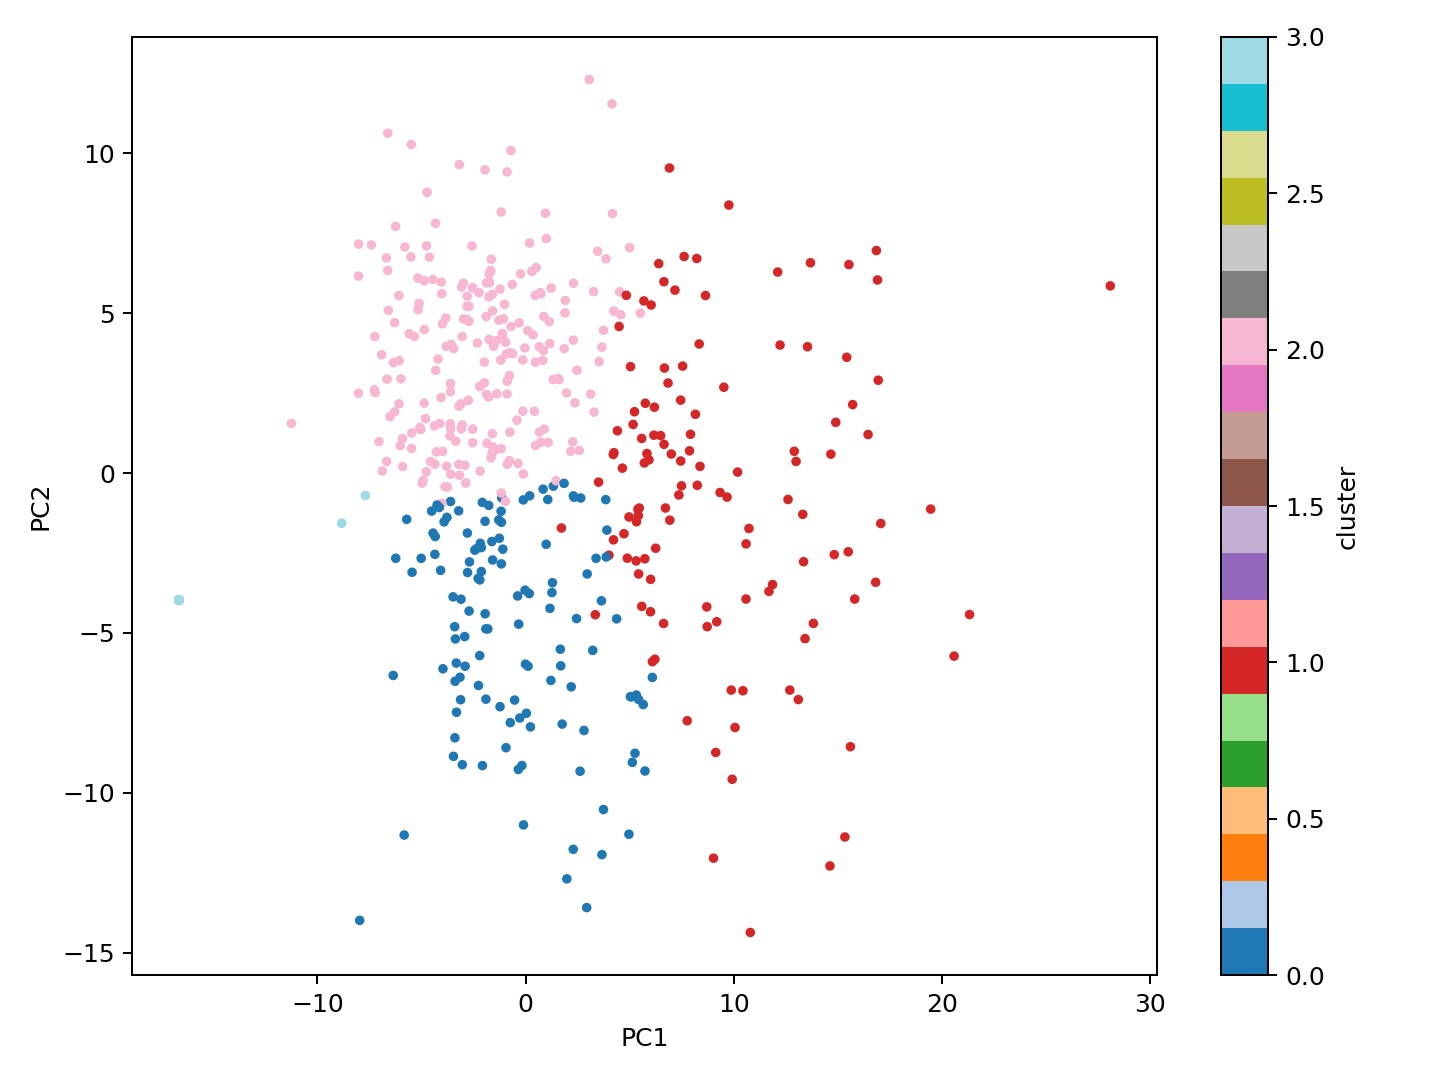

In [ ]:
from IPython.display import Image, display
pilot_plot = FIGURES / 'al_emadi_piloto' / 'clusters_pca.png'
if pilot_plot.exists():
    display(Image(filename=str(pilot_plot, width=500)))
else:
    print('Execute a etapa de plotagem do piloto para criar clusters_pca.png.')

## 3 — Diagnóstico pós-hoc: por que balancear?

**Pergunta.** O que os clusters do piloto representam quando observamos os rótulos somente depois do ajuste?

A tabela e o heatmap abaixo mostram a proporção de `bebop_1`, `membo_1` e `unknown` em cada cluster. Este cruzamento é diagnóstico, não é uma etapa de treinamento.

**Critério de leitura.** Se todos os clusters forem dominados por `unknown`, a amostra aleatória não permite avaliar bem separação entre os dois modelos de drone. Nesse caso, o experimento balanceado é uma correção de desenho, e não uma tentativa de forçar artificialmente um resultado.

label_for_description,bebop_1,membo_1,unknown
cluster,,,
0,2.4%,1.6%,95.9%
1,0.0%,0.0%,100.0%
2,12.7%,8.2%,79.1%
3,0.0%,0.0%,100.0%


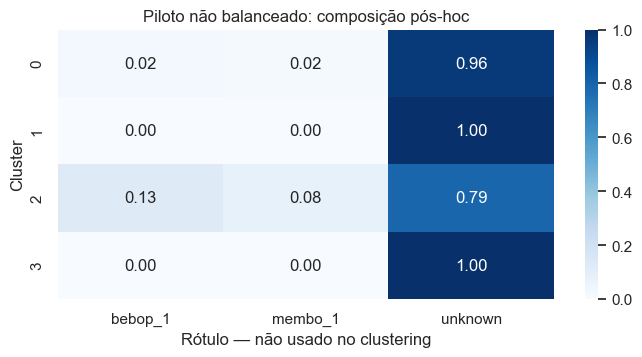

In [4]:
manifest = pd.read_csv(MANIFESTS / 'al_emadi.csv')
clusters = pd.read_csv(MODELS / 'al_emadi_piloto' / 'clusters_kmeans_k4.csv')
posthoc = clusters.merge(manifest[['filepath', 'label_for_description']], on='filepath', how='left')
composition = pd.crosstab(posthoc.cluster, posthoc.label_for_description, normalize='index')
display(composition.style.format('{:.1%}'))
plt.figure(figsize=(8, 3.5))
sns.heatmap(composition, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Piloto não balanceado: composição pós-hoc')
plt.xlabel('Rótulo — não usado no clustering'); plt.ylabel('Cluster'); plt.show()

## 4 — Experimento controlado: manifesto balanceado

**Conclusão da etapa anterior.** O piloto revelou que a maior parte da estrutura encontrada era compatível com subtipos de `unknown`; portanto, ele não respondia adequadamente à pergunta sobre assinaturas dos drones.

**Nova hipótese H2.** Com maior presença relativa de `bebop_1` e `membo_1`, uma representação acústica adequada pode produzir clusters cuja composição reflita, ao menos parcialmente, esses grupos.

Usamos 1.000 áudios: 250 `bebop_1`, 250 `membo_1` e 500 `unknown`. A razão 1:1 entre os drones preserva comparabilidade; `unknown` recebe o dobro para manter diversidade de ruído sem dominar todo o espaço. A seleção é estratificada e reproduzível, mas os rótulos seguem ausentes do clustering.

In [5]:
balanced_manifest = MANIFESTS / 'al_emadi_balanceado.csv'
if RUN_PIPELINE or not balanced_manifest.exists():
    subprocess.run([sys.executable, str(SCRIPTS / '01_build_manifest.py'), '--dataset', 'al_emadi',
                    '--per-label', 'bebop_1=250,membo_1=250,unknown=500',
                    '--output', str(balanced_manifest)], check=True)
balanced = pd.read_csv(balanced_manifest)
display(balanced.label_for_description.value_counts().rename_axis('rótulo').to_frame('áudios'))

,áudios
rótulo,
unknown,500
membo_1,250
bebop_1,250


## 5 — Baseline STFT no conjunto balanceado

**Hipótese H3.** O balanceamento melhora a separabilidade observada no piloto, mas a STFT pode ainda priorizar variações de energia/espectro presentes dentro de `unknown`.

**Procedimento.** Mantemos a mesma STFT (Hann, 40 ms, hop 20 ms) e testamos K-Means com `k` de 2 a 12. Comparamos as configurações por silhouette (maior é melhor), Calinski–Harabasz (maior é melhor) e Davies–Bouldin (menor é melhor).

**O que esperamos observar.** Se `k=2` ou `k=3` superar valores maiores, isso indica uma organização mais grossa e não muitos grupos naturais. Valores de `k` altos só são defensáveis se melhorarem de forma consistente as três métricas e produzirem clusters com tamanho razoável.

In [6]:
RUN_PIPELINE = True

balanced_stft = FEATURES / 'al_emadi_balanceado_stft.csv'
balanced_stft_models = MODELS / 'al_emadi_balanceado_stft'
balanced_stft_metrics = METRICS / 'al_emadi_balanceado_stft.csv'
if RUN_PIPELINE:
    subprocess.run([sys.executable, str(SCRIPTS / '02_extract_features.py'), str(balanced_manifest), '--output', str(balanced_stft)], check=True)
    subprocess.run([sys.executable, str(SCRIPTS / '03_cluster.py'), str(balanced_stft), '--output-dir', str(balanced_stft_models)], check=True)
    subprocess.run([sys.executable, str(SCRIPTS / '04_evaluate_internal.py'), str(balanced_stft), str(balanced_stft_models), '--output', str(balanced_stft_metrics)], check=True)
if balanced_stft_metrics.exists():
    display(pd.read_csv(balanced_stft_metrics).sort_values('silhouette', ascending=False))
else:
    print('Mude RUN_PIPELINE para True nesta célula para executar o baseline STFT.')

,run,samples,clusters,silhouette,calinski_harabasz,davies_bouldin
3,clusters_kmeans_k3,1000,3,0.281735,141.375243,1.827448
2,clusters_kmeans_k2,1000,2,0.255182,149.082986,2.352201
4,clusters_kmeans_k4,1000,4,0.170037,133.297260,1.858019
5,clusters_kmeans_k5,1000,5,0.138995,117.906928,1.982802
6,clusters_kmeans_k6,1000,6,0.133572,103.288946,2.199926
7,clusters_kmeans_k8,1000,8,0.133560,82.609704,2.457167
0,clusters_kmeans_k10,1000,10,0.110953,70.561295,2.602417
1,clusters_kmeans_k12,1000,12,0.077054,63.244973,2.558090


## 6 — Comparação multirresolução: wavelets DWT

**Conclusão da etapa 5.** No conjunto balanceado, STFT + K-Means melhorou para `k=3`, silhouette ≈ **0,282** e Davies–Bouldin ≈ **1,827**. O ganho sobre o piloto confirma que o desbalanceamento era um fator relevante, mas a separação ainda é moderada.

**Hipótese H4.** Uma decomposição multirresolução pode representar melhor o caráter não estacionário do ruído das hélices e separar regimes acústicos com mais nitidez que a STFT.

A DWT é testada com `db4`, `sym5` e `coif5`, nos níveis 4 e 5. Para cada combinação, extraímos energia relativa, entropia de Shannon e estatísticas dos coeficientes. Todas as seis configurações usam exatamente o mesmo manifesto de 1.000 áudios; portanto, diferenças de métricas podem ser atribuídas à representação, não à amostra.

In [7]:
if RUN_PIPELINE:
    subprocess.run([sys.executable, str(SCRIPTS / '02_extract_features.py'), str(balanced_manifest),
                    '--config', str(ROOT / 'config' / 'dwt_ablation.yaml'),
                    '--output', str(FEATURES / 'al_emadi_balanceado_dwt.csv')], check=True)
    for feature_file in sorted(FEATURES.glob('al_emadi_balanceado_dwt__*.csv')):
        output_dir = MODELS / feature_file.stem
        subprocess.run([sys.executable, str(SCRIPTS / '03_cluster.py'), str(feature_file), '--output-dir', str(output_dir)], check=True)
        subprocess.run([sys.executable, str(SCRIPTS / '04_evaluate_internal.py'), str(feature_file), str(output_dir),
                        '--output', str(METRICS / f'{feature_file.stem}.csv')], check=True)
dwt_metric_files = sorted(METRICS.glob('al_emadi_balanceado_dwt__*.csv'))
if dwt_metric_files:
    dwt_summary = pd.concat([pd.read_csv(f).assign(representation=f.stem) for f in dwt_metric_files])
    display(dwt_summary.sort_values('silhouette', ascending=False).head(12))
else:
    print('Mude RUN_PIPELINE para True nesta célula para executar a ablação DWT.')

,run,samples,clusters,silhouette,calinski_harabasz,davies_bouldin,representation
2,clusters_kmeans_k2,1000,2,0.494910,182.844580,1.618158,al_emadi_balanceado_dwt__sym5_L4
2,clusters_kmeans_k2,1000,2,0.481070,171.852449,1.681442,al_emadi_balanceado_dwt__coif5_L4
2,clusters_kmeans_k2,1000,2,0.446515,166.701236,1.874923,al_emadi_balanceado_dwt__sym5_L5
4,clusters_kmeans_k4,1000,4,0.313123,141.135138,1.468082,al_emadi_balanceado_dwt__db4_L4
3,clusters_kmeans_k3,1000,3,0.302456,184.414997,1.469591,al_emadi_balanceado_dwt__db4_L4
3,clusters_kmeans_k3,1000,3,0.297746,175.013319,1.528488,al_emadi_balanceado_dwt__coif5_L4
4,clusters_kmeans_k4,1000,4,0.286027,127.438880,1.307572,al_emadi_balanceado_dwt__sym5_L5
3,clusters_kmeans_k3,1000,3,0.284839,166.023739,1.659841,al_emadi_balanceado_dwt__sym5_L5
6,clusters_kmeans_k6,1000,6,0.238188,133.076643,1.525954,al_emadi_balanceado_dwt__db4_L4
5,clusters_kmeans_k5,1000,5,0.237632,147.746395,1.565840,al_emadi_balanceado_dwt__db4_L4


## 7 — Comparação e visualização da configuração vencedora

**Resultado da etapa 6.** DWT `sym5`, nível 4, com K-Means e `k=2` foi a melhor candidata: silhouette ≈ **0,490**, Calinski–Harabasz ≈ **182,8** e Davies–Bouldin ≈ **1,62**. Ela melhora substancialmente a separação interna em relação ao melhor STFT.

**Pergunta de interpretação.** Essa geometria mais clara corresponde aos modelos de drone ou a outro fator acústico? A resposta não vem da silhouette: ela mede apenas separação geométrica. Por isso, a próxima célula compara a composição dos clusters com os rótulos conhecidos, apenas após selecionar a configuração.

**Cuidado visual.** PCA é usado para comunicação. Pontos próximos no gráfico sugerem semelhança na projeção, mas o gráfico não substitui a análise no espaço original de atributos.

In [8]:
# Configuração vencedora observada no experimento balanceado.
winner_features = FEATURES / 'al_emadi_balanceado_dwt__sym5_L4.csv'
winner_clusters = MODELS / 'al_emadi_balanceado_dwt__sym5_L4' / 'clusters_kmeans_k2.csv'
if winner_features.exists() and winner_clusters.exists():
    result = pd.read_csv(winner_features).merge(pd.read_csv(winner_clusters)[['filepath', 'cluster']], on='filepath')
    posthoc = result[['filepath', 'cluster']].merge(balanced[['filepath', 'label_for_description']], on='filepath')
    composition = pd.crosstab(posthoc.cluster, posthoc.label_for_description, normalize='index')
    display(composition.style.format('{:.1%}'))
else:
    print('Execute as etapas 5 e 6 antes de interpretar a configuração vencedora.')

label_for_description,bebop_1,membo_1,unknown
cluster,,,
0,26.9%,27.2%,45.9%
1,4.6%,2.3%,93.1%


### Conclusão da comparação STFT × DWT

No STFT com `k=3`, dois clusters são quase exclusivamente `unknown` (≈94% e 100%); o terceiro mistura `bebop_1`, `membo_1` e `unknown`. Na melhor DWT, um cluster é ≈93% `unknown` e o outro continua misturando os dois modelos de drone com parte de `unknown`.

Portanto, a conclusão rigorosa é: **DWT `sym5` nível 4 encontra dois regimes acústicos mais separáveis, mas ainda não distingue de forma limpa `bebop_1` de `membo_1`.** As figuras abaixo tornam essa conclusão auditável. As cores representam clusters descobertos, não rótulos verdadeiros.

STFT Hann — K-Means k=3


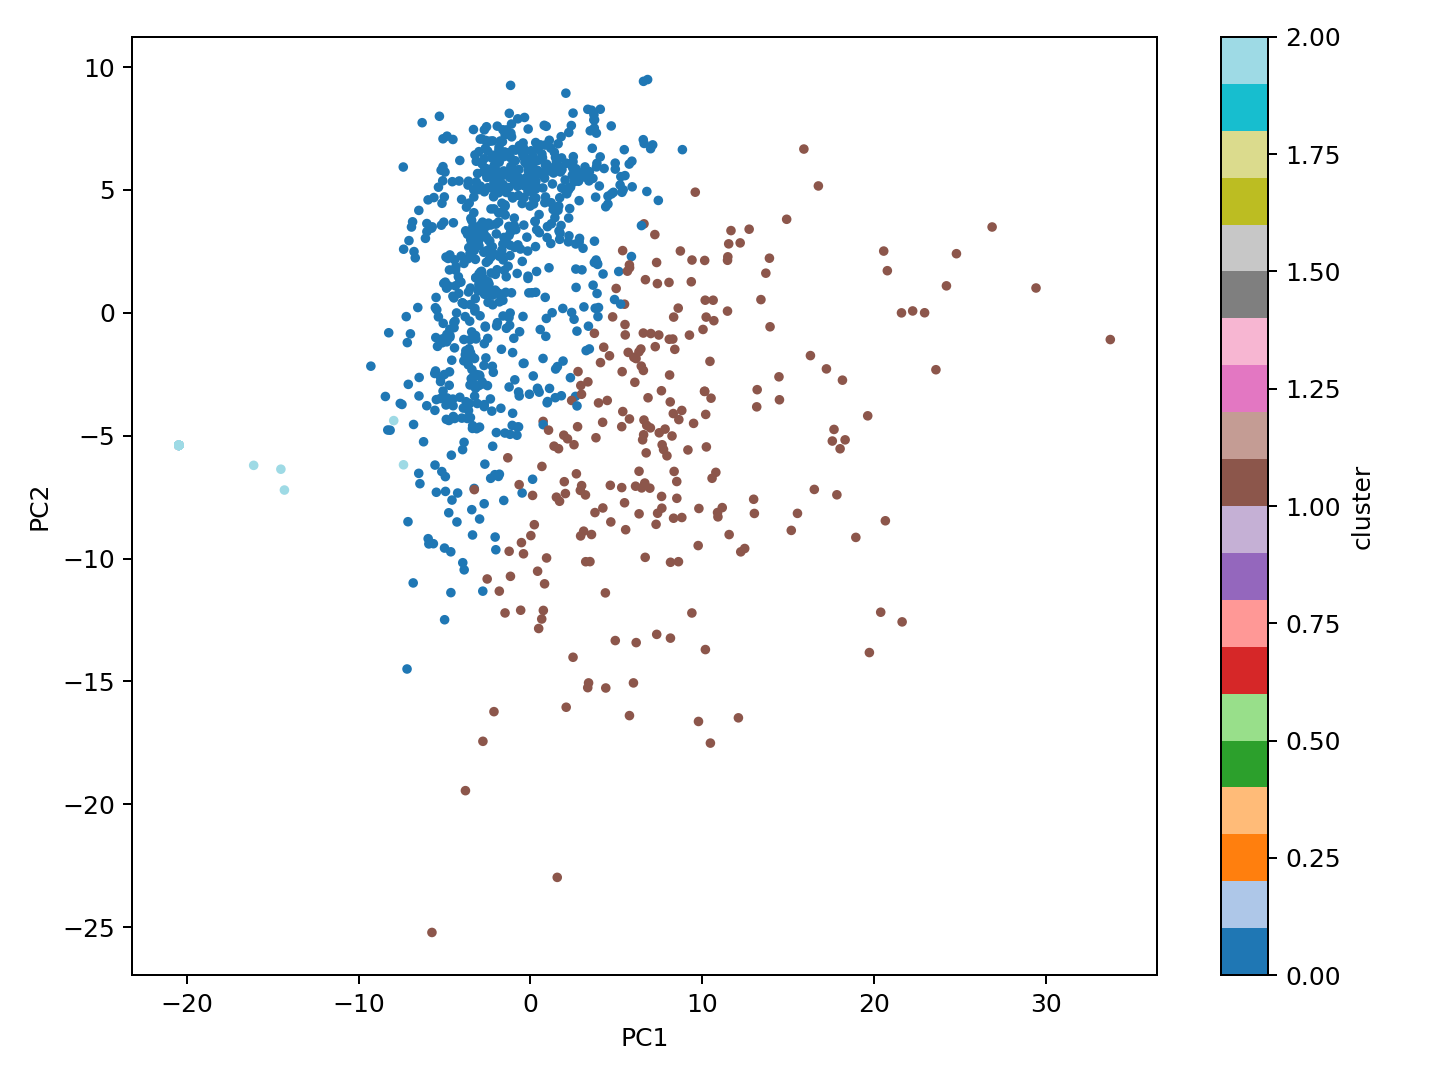

,bebop_1,membo_1,unknown
cluster,,,
0,34.3%,33.1%,32.6%
1,1.3%,4.7%,94.0%
2,0.0%,0.0%,100.0%


DWT sym5 nível 4 — K-Means k=2


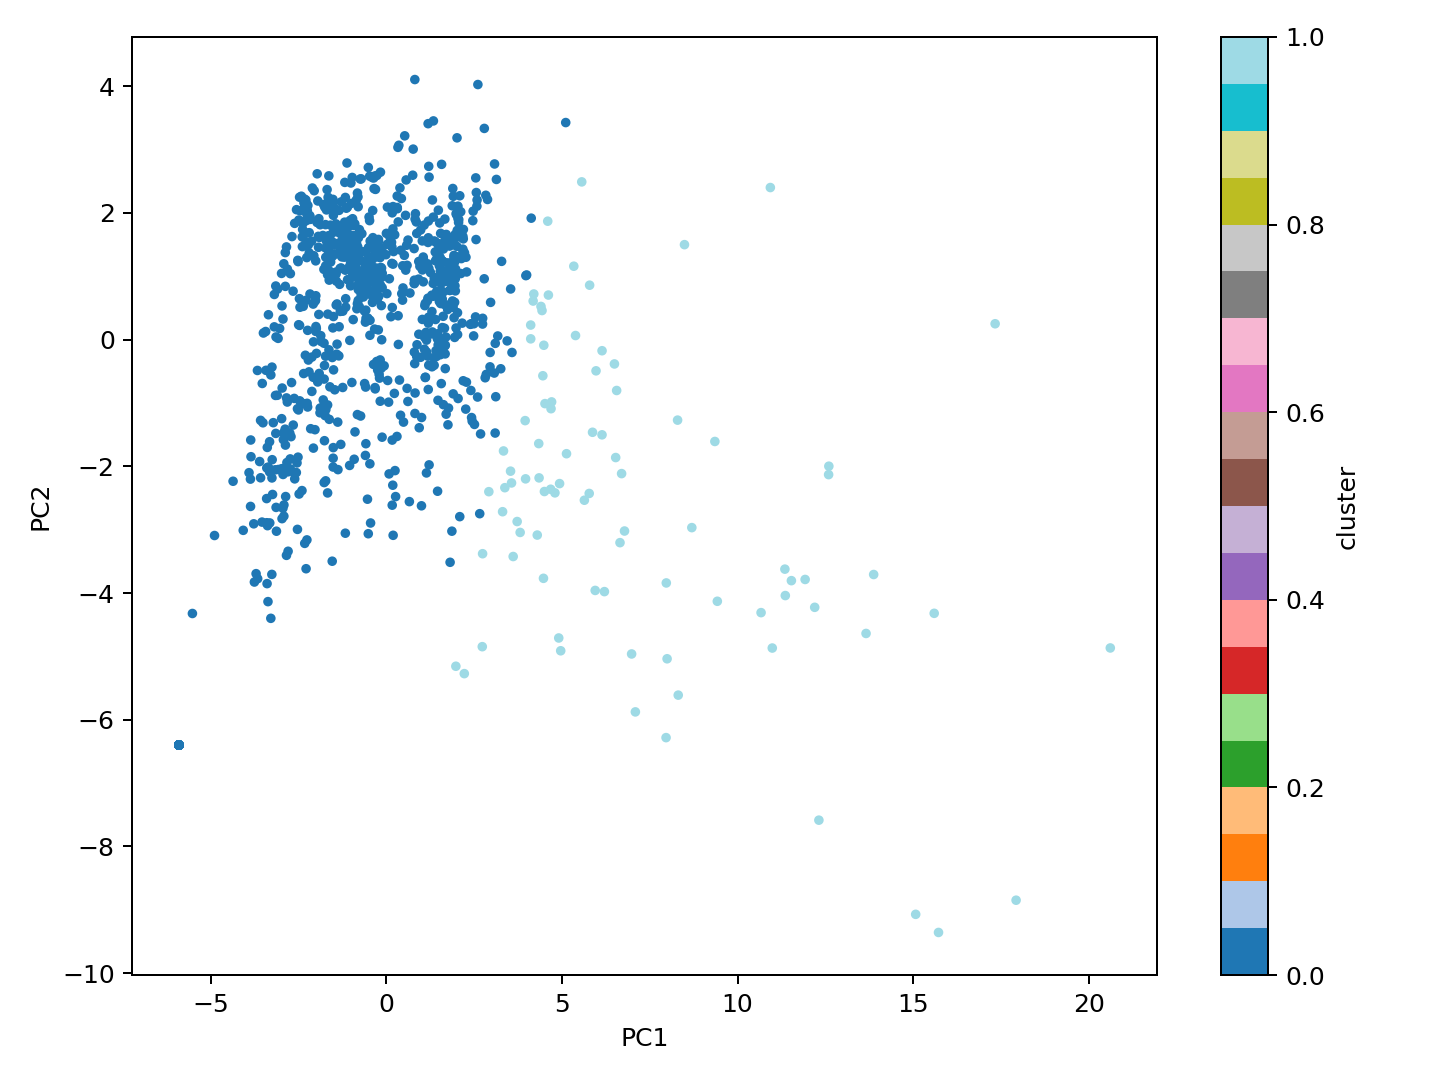

,bebop_1,membo_1,unknown
cluster,,,
0,26.9%,27.2%,45.9%
1,4.6%,2.3%,93.1%


In [9]:
from IPython.display import Image, display
for title, folder in [('STFT Hann — K-Means k=3', FIGURES / 'al_emadi_balanceado_stft_k3'), ('DWT sym5 nível 4 — K-Means k=2', FIGURES / 'al_emadi_balanceado_dwt_sym5_L4_k2')]:
    print(title)
    image = folder / 'clusters_pca.png'
    composition_file = folder / 'cluster_composition_posthoc.csv'
    if image.exists(): display(Image(filename=str(image)))
    if composition_file.exists(): display(pd.read_csv(composition_file, index_col='cluster').style.format('{:.1%}'))

## 8 — Comparação de algoritmos no mesmo conjunto balanceado

**Hipótese H5.** A representação vencedora não garante que K-Means seja o melhor algoritmo. Como K-Means pressupõe grupos aproximadamente esféricos e de variância semelhante, GMM, hierárquico e HDBSCAN podem descrever melhor uma estrutura alongada, hierárquica ou com ruído.

**Desenho justo.** Fixamos DWT `sym5` nível 4 e o mesmo conjunto de 1.000 áudios. Assim, a única variável que muda é o algoritmo. K-Means, GMM e hierárquico testam `k=2…6`; no HDBSCAN, o parâmetro testado é `min_cluster_size`, pois o número de clusters é inferido pelo método.

**Como decidir.** Procuramos simultaneamente silhouette alto, Davies–Bouldin baixo, número de clusters interpretável, tamanhos não degenerados e, no HDBSCAN, proporção de ruído aceitável. Nenhuma métrica isolada deve decidir o vencedor.

In [10]:
algorithm_configs = {
    'kmeans': ROOT / 'config' / 'algorithms' / 'kmeans.yaml',
    'gmm': ROOT / 'config' / 'algorithms' / 'gmm.yaml',
    'hierarchical': ROOT / 'config' / 'algorithms' / 'hierarchical.yaml',
    'hdbscan': ROOT / 'config' / 'algorithms' / 'hdbscan.yaml',
}
comparison_features = FEATURES / 'al_emadi_balanceado_dwt__sym5_L4.csv'
if RUN_PIPELINE:
    for algorithm, config in algorithm_configs.items():
        output_dir = MODELS / 'al_emadi_balanceado_dwt_sym5_L4' / algorithm
        metric_file = METRICS / f'al_emadi_balanceado_dwt_sym5_L4__{algorithm}.csv'
        subprocess.run([sys.executable, str(SCRIPTS / '03_cluster.py'), str(comparison_features), '--config', str(config), '--output-dir', str(output_dir)], check=True)
        subprocess.run([sys.executable, str(SCRIPTS / '04_evaluate_internal.py'), str(comparison_features), str(output_dir), '--output', str(metric_file)], check=True)
comparison_files = sorted(METRICS.glob('al_emadi_balanceado_dwt_sym5_L4__*.csv'))
if comparison_files:
    algorithm_table = pd.concat([pd.read_csv(path).assign(algorithm=path.stem.rsplit('__', 1)[-1]) for path in comparison_files])
    display(algorithm_table.sort_values(['silhouette', 'davies_bouldin'], ascending=[False, True]))
else:
    print('Mude RUN_PIPELINE para True para executar a comparação de algoritmos.')

,run,samples,clusters,silhouette,calinski_harabasz,davies_bouldin,algorithm
0,clusters_hierarchical_k2,1000,2,0.544881,169.711058,1.623407,hierarchical
0,clusters_kmeans_k2,1000,2,0.494910,182.844580,1.618158,kmeans
1,clusters_hierarchical_k3,1000,3,0.454028,171.485896,1.323935,hierarchical
2,clusters_hdbscan_k30,1000,3,0.344479,145.865794,1.733332,hdbscan
0,clusters_hdbscan_k10,1000,3,0.323167,144.418745,1.738500,hdbscan
1,clusters_hdbscan_k20,1000,3,0.293659,144.224840,1.730476,hdbscan
2,clusters_kmeans_k4,1000,4,0.235784,173.459787,1.621922,kmeans
4,clusters_kmeans_k6,1000,6,0.212117,142.123202,1.674589,kmeans
3,clusters_kmeans_k5,1000,5,0.199858,156.312443,1.571752,kmeans
4,clusters_hierarchical_k6,1000,6,0.199486,132.508140,1.545507,hierarchical


## 9 — Robustez e validação externa pós-hoc

**Resultado da etapa 8.** No conjunto balanceado com DWT `sym5` nível 4, o agrupamento hierárquico com `k=2` obteve a melhor silhouette interna (≈ **0,545**), superando K-Means `k=2` (≈ **0,495**). Contudo, K-Means apresentou estabilidade limitada entre sementes (ARI médio ≈ **0,410**) e correspondência muito baixa com os rótulos (ARI ≈ **−0,039**; NMI ≈ **0,063**). Isso reforça que a geometria dominante não coincide com as três classes semânticas disponíveis.

**Por que esta etapa é necessária?** Uma boa métrica em uma única execução pode ser acidental. Repetir o algoritmo com várias sementes verifica se pequenas mudanças de inicialização levam ao mesmo particionamento. Para o hierárquico, que é determinístico sob a mesma entrada, o teste mais relevante será a persistência da estrutura ao mudar a amostra e ao passar ao conjunto completo.

**Estabilidade.** O ARI entre pares de execuções varia de −1 a 1; quanto mais próximo de 1, mais os agrupamentos se repetem. Para K-Means/GMM, esperamos ARI alto se a solução for robusta. Hierárquico é determinístico para a mesma entrada; HDBSCAN exige análise adicional da persistência e dos pontos marcados como ruído.

**Validação externa pós-hoc.** ARI e NMI entre clusters e rótulos conhecidos quantificam associação semântica depois do ajuste. Valores baixos não invalidam a descoberta geométrica: podem indicar que os clusters representam condições acústicas diferentes das classes disponíveis.

In [11]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

# Exemplo de estabilidade do K-Means escolhido; adapte k/algoritmo após a etapa 8.
if comparison_features.exists():
    feature_frame = pd.read_csv(comparison_features)
    ignored = {'filepath', 'relative_path', 'dataset', 'group_id', 'duration_seconds'}
    numeric = [c for c in feature_frame.select_dtypes('number').columns if c not in ignored]
    X = StandardScaler().fit_transform(feature_frame[numeric].fillna(feature_frame[numeric].median()))
    X = PCA(n_components=.95, random_state=42).fit_transform(X)
    labels_by_seed = [KMeans(n_clusters=2, random_state=seed, n_init='auto').fit_predict(X) for seed in range(20)]
    aris = [adjusted_rand_score(a, b) for a, b in combinations(labels_by_seed, 2)]
    print(f'Estabilidade K-Means k=2: ARI médio={sum(aris)/len(aris):.3f}; mínimo={min(aris):.3f}')

    selected = pd.read_csv(MODELS / 'al_emadi_balanceado_dwt__sym5_L4' / 'clusters_kmeans_k2.csv')
    labeled = selected.merge(balanced[['filepath', 'label_for_description']], on='filepath')
    print('ARI pós-hoc:', round(adjusted_rand_score(labeled.label_for_description, labeled.cluster), 3))
    print('NMI pós-hoc:', round(normalized_mutual_info_score(labeled.label_for_description, labeled.cluster), 3))

Estabilidade K-Means k=2: ARI médio=0.410; mínimo=-0.092
ARI pós-hoc: -0.039
NMI pós-hoc: 0.063


## 9A — Robustez, validação externa e decisão final

Para fechar a análise do Al Emadi, faltam dois passos decisivos: medir a estabilidade da solução em múltiplas sementes e testar a configuração vencedora no conjunto completo. A decisão final deve combinar quatro critérios simultaneamente: separação interna (silhouette), estabilidade (ARI), interpretabilidade dos clusters e consistência no conjunto completo.

A validação externa pós-hoc continua sendo apenas interpretativa, pois ela compara clusters descobertos com classes conhecidas depois do ajuste. Isso não substitui a análise do espaço acústico, mas evita atribuir significado a uma estrutura que não corresponde ao que os dados semânticos sugerem.



### Critério final de decisão

A escolha da configuração final deve obedecer a uma regra explícita e conservadora:

1. alta separação interna;
2. baixa sensibilidade a sementes e amostras;
3. clusters com tamanhos razoáveis e sem degeneração;
4. composição pós-hoc compatível com a hipótese de interesse.

Se um modelo atende somente ao critério 1, ele ainda não deve ser interpretado como assinatura estável de drone.



### Validação de robustez do algoritmo vencedor

A etapa de robustez verifica se a estrutura descoberta não depende de uma inicialização particular. Para isso, repetimos a mesma configuração com múltiplas sementes e calculamos a similaridade entre partições usando ARI.

A ideia é simples: se a solução for estável, pequenas mudanças no processo de otimização geram partições semelhantes. Se o ARI for baixo, a geometria descoberta é frágil e não deve ser interpretada como uma assinatura estável do áudio.

Neste ponto, a configuração candidata continua sendo DWT `sym5` nível 4. O objetivo é confirmar se o melhor desempenho interno persiste sob variação aleatória e se a estrutura lógica continua compatível com os rótulos conhecidos apenas em análise pós-hoc.

In [ ]:
# Robustez do algoritmo vencedor no conjunto balanceado
# Objetivo: verificar se a estrutura descoberto é estável sob diferentes sementes.

from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

comparison_features = FEATURES / 'al_emadi_balanceado_dwt__sym5_L4.csv'
if comparison_features.exists():
    feature_frame = pd.read_csv(comparison_features)
    ignored = {'filepath', 'relative_path', 'dataset', 'group_id', 'duration_seconds'}
    numeric = [c for c in feature_frame.select_dtypes('number').columns if c not in ignored]
    X = StandardScaler().fit_transform(feature_frame[numeric].fillna(feature_frame[numeric].median()))
    X = PCA(n_components=0.95, random_state=42).fit_transform(X)

    labels_by_seed = [KMeans(n_clusters=2, random_state=seed, n_init='auto').fit_predict(X) for seed in range(20)]
    aris = [adjusted_rand_score(a, b) for a, b in combinations(labels_by_seed, 2)]
    ari_mean = sum(aris) / len(aris)
    ari_min = min(aris)
    print(f'ARI médio entre sementes (K-Means k=2): {ari_mean:.3f}')
    print(f'ARI mínimo entre sementes (K-Means k=2): {ari_min:.3f}')
else:
    print('Primeiro execute a etapa de extração DWT e clustering do conjunto balanceado.')


## 10 — Validação no Al Emadi completo

**Hipótese H6.** A configuração vencedora no conjunto balanceado continuará encontrando estrutura no conjunto completo de 11.704 áudios, embora as métricas possam cair porque `unknown` volta a dominar a distribuição.

**Por que o completo importa?** O balanceado responde uma pergunta controlada sobre comparabilidade entre grupos; o completo testa robustez no cenário disponível na prática. Uma diferença entre ambos é informativa: ela mostra quanto o resultado depende da prevalência das classes e da diversidade de ruídos.

**Regra de economia experimental.** Não repetimos a busca de 36 STFTs e seis DWTs. Executamos apenas a representação e o algoritmo já justificados nas etapas 5–9. Antes de passar a DREGON ou Drone Audio, registramos se a conclusão se mantém, se os clusters viram majoritariamente `unknown` e se a estabilidade permanece aceitável.

In [ ]:
RUN_FULL_DATASET = False
full_manifest = MANIFESTS / 'al_emadi_completo.csv'
full_features = FEATURES / 'al_emadi_completo_dwt_sym5_L4.csv'
full_models = MODELS / 'al_emadi_completo_dwt_sym5_L4_hierarchical'
full_metrics = METRICS / 'al_emadi_completo_dwt_sym5_L4_hierarchical.csv'
if RUN_FULL_DATASET:
    subprocess.run([sys.executable, str(SCRIPTS / '01_build_manifest.py'), '--dataset', 'al_emadi', '--output', str(full_manifest)], check=True)
    subprocess.run([sys.executable, str(SCRIPTS / '02_extract_features.py'), str(full_manifest), '--config', str(ROOT / 'config' / 'dwt_sym5_L4.yaml'), '--output', str(full_features)], check=True)
    subprocess.run([sys.executable, str(SCRIPTS / '03_cluster.py'), str(full_features), '--config', str(ROOT / 'config' / 'algorithms' / 'hierarchical_k2.yaml'), '--output-dir', str(full_models)], check=True)
    subprocess.run([sys.executable, str(SCRIPTS / '04_evaluate_internal.py'), str(full_features), str(full_models), '--output', str(full_metrics)], check=True)
    print('Validação no dataset completo concluída.')
else:
    print('Mude RUN_FULL_DATASET para True somente após selecionar o algoritmo vencedor.')

# Interpretação pós-hoc do completo
if full_metrics.exists():
    full_metrics_df = pd.read_csv(full_metrics)
    display(full_metrics_df.sort_values('silhouette', ascending=False))
else:
    print('O dataset completo ainda não foi validado; rode a célula acima com RUN_FULL_DATASET=True.')


Mude RUN_FULL_DATASET para True somente após selecionar o algoritmo vencedor.


## 11 — Conclusões para apresentação

**Síntese do que já é suportado pelos dados.** As afirmações abaixo separam resultado observado de interpretação. Elas devem ser atualizadas após as etapas 8–10, mas já formam uma narrativa honesta para apresentar o progresso metodológico:

1. A representação com melhor estrutura interna foi: **DWT `sym5`, nível 4**.
2. No conjunto balanceado, o melhor algoritmo interno foi **hierárquico com `k=2`** (silhouette ≈ **0,545**); o baseline STFT preferiu K-Means com `k=3` (silhouette ≈ **0,282**).
3. No melhor resultado DWT, um cluster é majoritariamente `unknown` (≈93%); o outro mistura `bebop_1`, `membo_1` e `unknown`. Portanto, a estrutura dominante ainda separa regimes de ruído/áudio desconhecido, não os dois modelos de drone.
4. Limitações: `unknown` é heterogêneo; segmentos relacionados não são totalmente independentes; métricas internas não provam significado semântico.
5. Próximo teste decisivo: comparar algoritmos, verificar estabilidade e validar no Al Emadi completo. Só então aplicar a configuração vencedora ao DREGON e ao Drone Audio.

**Mensagem central do seminário até aqui.** Clustering não é apenas escolher um algoritmo: a representação temporal do sinal, o desenho amostral e a interpretação pós-hoc mudam substantivamente a estrutura que aparece nos dados.